# Introduction
---
This notebook is meant to give an overview on the functionality of the autoXPCS package

Each step of the analysis is described, so the data_loading can be exchanged to the desired beamline, while the rest of the analysis stays the same 

In [18]:
%load_ext autoreload
%autoreload 2
import numpy as np 
from pathlib import Path
import pyFAI
import time
import json
import sys 
sys.path.append('../.')
from data_loading import p10 as data_loader # only need to exchange the beamline  
from processing import proc_scans, proc_det, proc_saxs, proc_xpcs
from ploty import plotting

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Input

In [23]:
dir_beamtime = Path('./data/')

sample_name = 'm036_hiAmylose_starch'
scan_number = 45
detector = 'e4m'
skip_frames_start = 1

filename_mask = dir_beamtime / 'preliminary_mask.npy'
#filename_poni = dir_beamtime / 'processed/SAXSdetector_2025_08_31.poni' # if you don't have a poni file yet, you can use function 'create_poni_from_batchinfoP10(filename_batchinfo, pixel_size_m)' instead

dir_results = Path('output/.') # ToDo change according to scan_series etc.

# define the q-partitions
q_centers = np.arange(0.15,0.9,0.05) * 1e9
q_widths = 0.05*np.ones(len(q_centers)) * 1e9

# Processing

In [24]:
sample = proc_scans.Sample(dir_beamtime=dir_beamtime, sample_name=sample_name)
mask = proc_det.Mask(filename_mask=filename_mask)
experimental_parameters = {}

In [25]:
###############################################
### Load the raw data of the provided scan  ###
###############################################

# ScanSeries
time_start = time.time()
# create instances
scan_series = proc_scans.ScanSeries(sample=sample, detector=detector, scan_number=scan_number, skip_frames_start=skip_frames_start)
scan_series.add_mask(mask=mask)

# provide filenames
scan_series.add_filenames_raw_data(data_loader.get_filenames_series(scan_series))

# provide delay time and exposure time
delay_time_s, exposure_time_s = data_loader.get_delay_and_exposure_time(scan_series)
experimental_parameters.update({'delay_time_s': delay_time_s, 'exposure_time_s': exposure_time_s}) # update dictionary
scan_series.add_delay_time(delay_time_s, exposure_time_s)

# load data
scan_series.add_raw_data(raw_data=data_loader.load_data(scan_series.filenames_raw_data))
time_intermediate = time.time()
print(f'Took {time_intermediate - time_start:.3f} s for initialization and loading data.')

Took 3.630 s for initialization and loading data.


In [26]:
##################################################
### Provide pyFAI configuration via batchinfo  ###
##################################################

# load pyFAI configuration as poni file
pyFAI_config, experimental_params_config = data_loader.create_poni_from_batchinfo(scan_series)
experimental_parameters.update(experimental_params_config)
pyFAI_config.save(dir_results / 'pyfai_config.poni') # save pyFAI configuration as poni file
experimental_parameters['pyFAI_config'] = 'pyfai_config.poni'

In [28]:
##################################################
### Process the detector image using the mask  ###
##################################################
time_inter_start = time.time()
incoherent_img, incoherent_img_cor = proc_det.process_incoherent_image(data3D=scan_series.raw_data[scan_series.skip_frames_start:,:,:], mask=mask)
summary_incoherent_img = proc_scans.save_incoherent_image_results(dir_results, incoherent_img, incoherent_img_cor)
time_inter_end = time.time()
print(f'Took {time_inter_end - time_inter_start:.3f} s for calculating incoherent image.')

Took 0.767 s for calculating incoherent image.


In [29]:
################################
### Process SAXS information ###
################################

time_inter_start = time.time()
SAXS_Q, SAXS_IofQ, SAXS_errorIofQ = proc_saxs.process_SAXS(incoherent_img, pyFAI_config, precision_SAXS=600, mask=mask)
summary_SAXS = proc_scans.save_SAXS_results(dir_results, 'SAXS', SAXS_Q, SAXS_IofQ, SAXS_errorIofQ)
time_inter_end = time.time()
print(f'Took {time_inter_end - time_inter_start:.3f} s for total SAXS curve.')

time_inter_start = time.time()
frame_resolved_SAXS_Q, frame_resolved_SAXS_IofQ, frame_resolved_errorIofQ = proc_saxs.process_frame_resolved_SAXS(scan_series.raw_data[scan_series.skip_frames_start:,:,:], pyFAI_config, precision_SAXS=600, mask=mask)
summary_frame_resolved_SAXS = proc_scans.save_SAXS_results(dir_results, 'frame_resolved_SAXS', frame_resolved_SAXS_Q, frame_resolved_SAXS_IofQ, frame_resolved_errorIofQ)
time_inter_end = time.time()
print(f'Took {time_inter_end - time_inter_start:.3f} s for frame resolved SAXS processing.')

time_inter_start = time.time()
evo_SAXS_Q, evo_SAXS_IofQ, evo_SAXS_errorIofQ = proc_saxs.evolution_SAXS(scan_series.raw_data[scan_series.skip_frames_start:,:,:], pyFAI_config, precision_SAXS=600, segments=10, mask=mask)
summary_evo_SAXS = proc_scans.save_SAXS_results(dir_results, 'evolution_SAXS', evo_SAXS_Q, evo_SAXS_IofQ, evo_SAXS_errorIofQ)
time_inter_end = time.time()
print(f'Took {time_inter_end - time_inter_start:.3f} s for evolution of SAXS data.')

Took 0.855 s for total SAXS curve.
Took 14.824 s for frame resolved SAXS processing.
Took 1.600 s for evolution of SAXS data.


In [30]:
################################
### Process XPCS information ###
################################

time_inter_start = time.time()
q_rings = proc_det.QRings()
q_rings.q_partitions_from_q_rings(q_centers=q_centers, q_widths=q_widths, detector_shape=(mask.dim_y, mask.dim_x), poni_info=pyFAI_config)
q_partitions = proc_det.QPartitions()
q_partitions.define_partitions(partition_arrays=q_rings.arrays, info=q_rings.info)
summary_partitions = proc_scans.save_Q_partitions(dir_results, q_partitions)
scan_series.input['q_partitions'] = summary_partitions
time_inter_end = time.time()
print(f'Took {time_inter_end - time_inter_start:.3f} s for defining Q-partitions.')

time_inter_start = time.time()
intensities_per_q_partition, ttc_per_q_partition, pixels_per_q_partition = scan_series.calculate_ttcfs(q_partitions=q_partitions)
summary_ttc = proc_scans.save_results_TTCF(dir_results, intensities_per_q_partition, ttc_per_q_partition, pixels_per_q_partition)
time_inter_end = time.time()
print(f'Took {time_inter_end - time_inter_start:.3f} s for calculating ttcfs.')

time_inter_start = time.time()
g2_from_ttcs = scan_series.calculate_all_g2s(ttc_per_q_partition)
times_g2_from_ttcs_s = np.arange(g2_from_ttcs.shape[-1])*experimental_parameters['delay_time_s'] + experimental_parameters['delay_time_s']
summary_g2_from_ttc = proc_scans.save_results_g2(dir_results, 'g2_from_ttc', times_g2_from_ttcs_s, g2_from_ttcs)
time_inter_end = time.time()
print(f'Took {time_inter_end - time_inter_start:.3f} s for calculating g2s from ttcfs.')

time_inter_start = time.time()
times_multitau, g2multitau_per_q_partition, g2errormultitau_per_q_partition = scan_series.calculate_g2s_multitau(q_partitions)
times_multitau = times_multitau*experimental_parameters['delay_time_s']
summary_g2_multitau = proc_scans.save_results_g2(dir_results, 'g2_multitau', times_multitau, g2multitau_per_q_partition)
time_inter_end = time.time()
print(f'Took {time_inter_end - time_inter_start:.3f} s for calculating g2s via multitau.')

# output
dict_summary = {}
dict_summary['input'] = scan_series.input
dict_summary['experimental_parameters'] = experimental_parameters
dict_summary['results_incoherent_image'] = summary_incoherent_img
dict_summary['results_SAXS'] = summary_SAXS
dict_summary['results_frame_resolved_SAXS'] = summary_frame_resolved_SAXS
dict_summary['results_evolution_SAXS'] = summary_evo_SAXS
dict_summary['results_ttc'] = summary_ttc
dict_summary['results_g2_from_ttc'] = summary_g2_from_ttc
dict_summary['results_g2_multitau'] = summary_g2_multitau
with open(dir_results / 'input_output_summary.json', "w") as f:
    json.dump(dict_summary, f, indent=4, default=proc_det.custom_encoder)


time_end = time.time()
print(f'Took {time_end - time_start:.3f} s for processing.')

Took 0.904 s for defining Q-partitions.
Took 2.751 s for calculating ttcfs.
Took 0.046 s for calculating g2s from ttcfs.
Took 31.773 s for calculating g2s via multitau.
Took 277.084 s for processing.


# Visualization

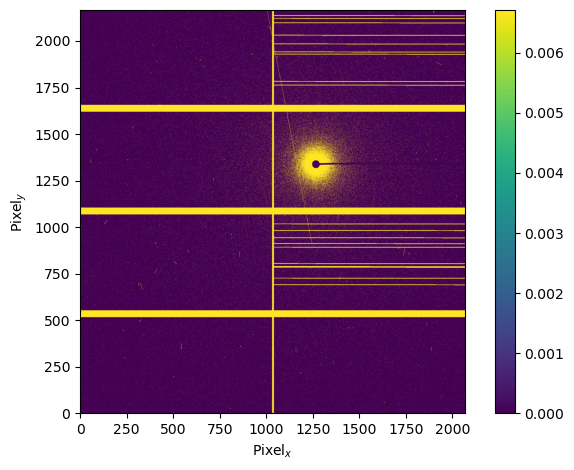

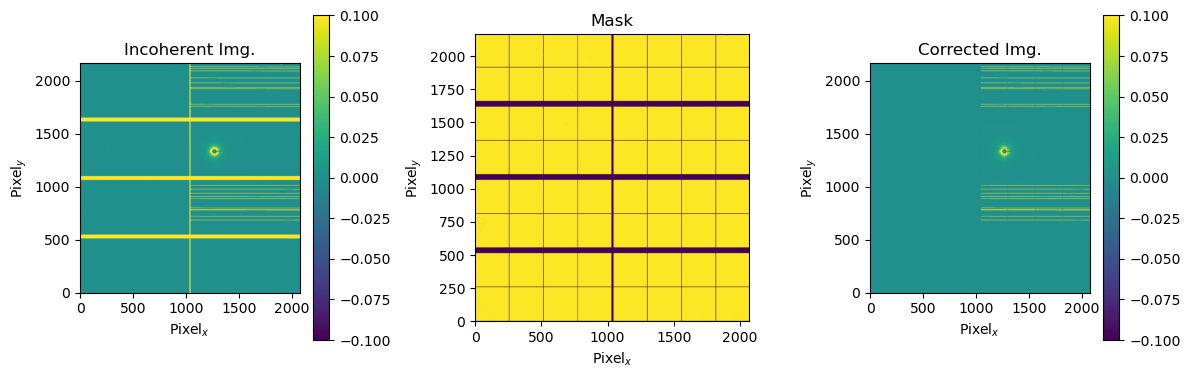

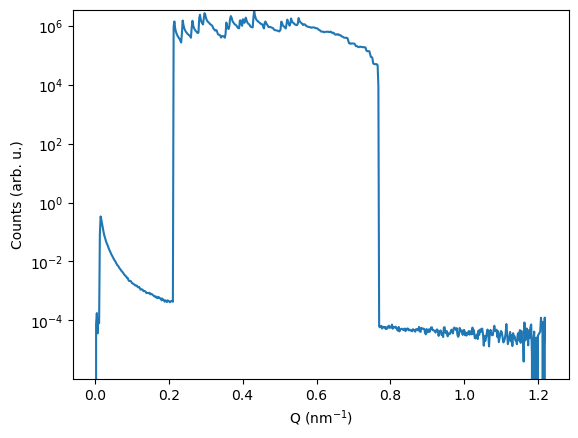

ValueError: Invalid vmin or vmax

Error in callback <function _draw_all_if_interactive at 0x000001B8196A7D80> (for post_execute), with arguments args (),kwargs {}:


ValueError: Invalid vmin or vmax

ValueError: Invalid vmin or vmax

<Figure size 1400x400 with 4 Axes>

In [31]:
# incoherent images (2 options)
plotting.show_incoherent_img(incoherent_img)
plotting.show_incoherent_img(incoherent_img, mask=mask, v_limits='auto')
# SAXS curves 
plotting.show_SAXS_curve(SAXS_Q, SAXS_IofQ) # converts automatically to nm-1
# evolution/degradation
plotting.show_evolution_plots(evo_SAXS_Q*1e-9, evo_SAXS_IofQ)
plotting.show_evolution_plots(frame_resolved_SAXS_Q*1e-9, frame_resolved_SAXS_IofQ, norm_reference_idx=0)
# ttcf
plotting.show_single_ttcf(ttc_per_q_partition[9,:,:], v_limits='auto')
plotting.show_all_ttcf(ttc_per_q_partition, v_limits='auto')
# g2
plotting.show_single_g2(times_multitau, g2multitau_per_q_partition[9,:],g2error=g2errormultitau_per_q_partition[9,:] ,y_limits='auto')
plotting.show_all_g2s(times_multitau, g2multitau_per_q_partition[7:12,:],g2errors=g2errormultitau_per_q_partition[7:12,:] ,y_limits=[1,1.07])
# q_partitions
detector.q_partitions.show_partitions2D(incoherent_img=incoherent_img_cor)
detector.q_rings.show_q_rings(SAXS_Q, SAXS_IofQ)